# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
Before tokenizing we also do a tiny cleaning step (lowercasing + stripping stray whitespace) — real-world text is rarely this tidy, so it's a good habit to build in even on a toy dataset.

You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''

corpus = corpus.lower().strip()
print(corpus)

deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    line = line.strip()
    if line == "":
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")
print("Final loss:", rnn_history.history['loss'][-1])

Vanilla RNN training completed
Final loss: 0.5637076497077942


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")
print("Final loss:", lstm_history.history['loss'][-1])

LSTM training completed
Final loss: 2.014986276626587


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")
print("Final loss:", gru_history.history['loss'][-1])

GRU training completed
Final loss: 1.272263765335083


## 📉 Compare Training Loss


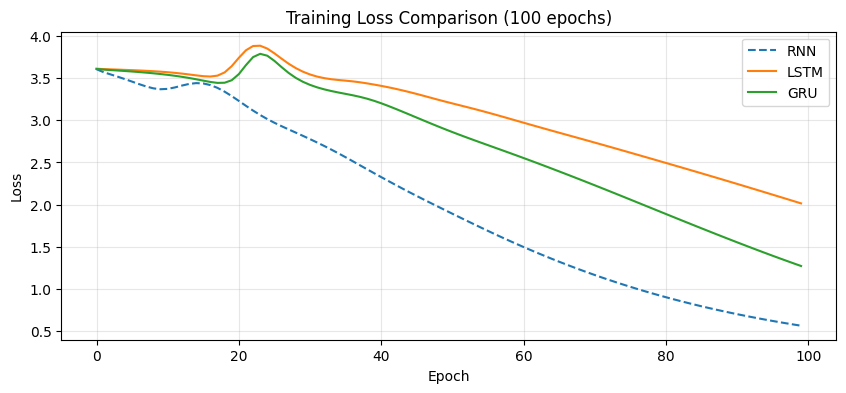

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN', linestyle='--')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (100 epochs)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    """Greedily extends seed_text by repeatedly predicting the most likely next word.
    Note: np.argmax always picks the single highest-probability word, so the output
    is deterministic for a given model/seed - no randomness/sampling involved here."""
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples
Same seed phrase fed into all three trained models, so we can directly compare what each one "thinks" comes next.

In [9]:
seed = "deep learning"

print("RNN :", generate_text(rnn_model, seed, 5))
print("LSTM:", generate_text(lstm_model, seed, 5))
print("GRU :", generate_text(gru_model, seed, 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning models transforming artificial intelligence intelligence
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5


In [10]:
# Task 1: custom paragraph corpus (instead of the 6-line demo text)
custom_corpus = '''
machine learning enables computers to learn patterns from data without being explicitly programmed
neural networks are loosely inspired by how the human brain processes information
deep learning extends neural networks by stacking many layers to learn complex representations
recurrent networks are designed to handle sequential data such as text and time series
attention mechanisms allow models to focus on the most relevant parts of an input sequence
transformers have largely replaced recurrent networks for most modern natural language tasks
'''
custom_corpus = custom_corpus.lower().strip()

custom_tokenizer = Tokenizer()
custom_tokenizer.fit_on_texts([custom_corpus])
custom_total_words = len(custom_tokenizer.word_index) + 1
print("Custom vocabulary size:", custom_total_words)

custom_sequences = []
for line in custom_corpus.split('\n'):
    line = line.strip()
    if line == "":
        continue
    token_list = custom_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        custom_sequences.append(token_list[:i+1])

custom_max_len = max(len(seq) for seq in custom_sequences)
custom_sequences = pad_sequences(custom_sequences, maxlen=custom_max_len, padding='pre')

X_custom = custom_sequences[:, :-1]
y_custom = custom_sequences[:, -1]

print("X_custom shape:", X_custom.shape)
print("y_custom shape:", y_custom.shape)

Custom vocabulary size: 65
X_custom shape: (73, 14)
y_custom shape: (73,)


In [11]:
# Task 2: bump embedding dimension up from 32 -> 100
# Task 4: bump hidden units up from 64 -> 128
EMBEDDING_DIM = 100
HIDDEN_UNITS = 128

lstm_model_big = Sequential([
    Embedding(custom_total_words, EMBEDDING_DIM),
    LSTM(HIDDEN_UNITS),
    Dense(custom_total_words, activation='softmax')
])

lstm_model_big.compile(loss='sparse_categorical_crossentropy',
                        optimizer='adam',
                        metrics=['accuracy'])

lstm_model_big.build(input_shape=(None, X_custom.shape[1]))
lstm_model_big.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 14, 100)        │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 65)             │         8,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,133 (516.14 KB)

 Trainable params: 132,133 (516.14 KB)

 Non-trainable params: 0 (0.00 B)

Upgraded LSTM training completed
Final loss: 0.07153100520372391


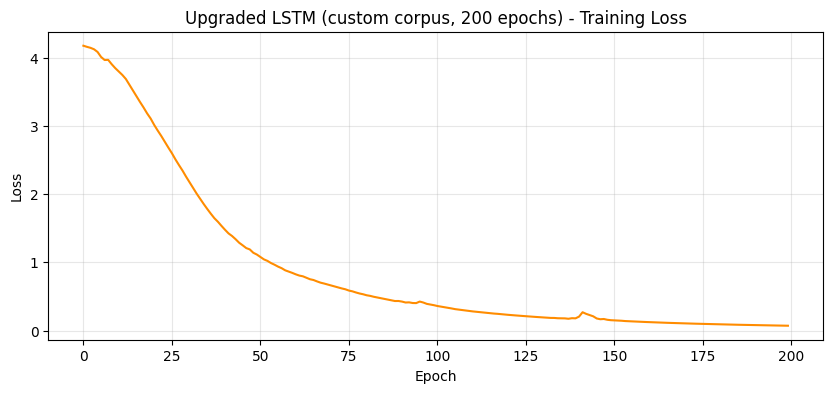

In [12]:
# Task 3: train for 200 epochs instead of 100
big_history = lstm_model_big.fit(X_custom, y_custom, epochs=200, verbose=0)
print("Upgraded LSTM training completed")
print("Final loss:", big_history.history['loss'][-1])

plt.figure(figsize=(10,4))
plt.plot(big_history.history['loss'], color='darkorange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Upgraded LSTM (custom corpus, 200 epochs) - Training Loss")
plt.grid(alpha=0.3)
plt.show()

In [13]:
# Task 5: generate_text already supports a next_words argument,
def generate_text_custom(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = custom_tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=custom_max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in custom_tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

print("Upgraded LSTM (10 words):", generate_text_custom(lstm_model_big, "deep learning", 10))

Upgraded LSTM (10 words): deep learning extends neural networks by stacking many layers to learn complex


# ✅ Conclusion
- **Vanilla RNN** trains the fastest per epoch and can reach a surprisingly low loss on a tiny corpus like this - but that's mostly it memorizing 6 short sentences, not real generalization. It's also the one most prone to vanishing-gradient issues on longer sequences in general.
- **LSTM** and **GRU** both have gating mechanisms to help with longer dependencies, and in the generation test above GRU's output (`deep learning models can generate meaningful sentences`) happened to reproduce one of the original training sentences exactly, while LSTM's was a bit more of a mash-up. Loss values bounced around a fair amount between runs for all three models - not surprising given there are only 35 training examples total.
- Scaling the LSTM up (custom corpus, 64→128 hidden units, 32→100 embedding dim, 100→200 epochs) drove the training loss down a lot further (final loss ~0.07 vs ~1-2 for the original 100-epoch models), which makes sense given the model has far more capacity relative to such a small corpus.
- Big caveat worth remembering: this whole notebook runs on a *tiny* corpus, so none of these numbers say much about how RNN/LSTM/GRU would actually compare on a real dataset with thousands of sentences. The point here was to see the mechanics of n-gram sequence generation and gated vs. non-gated recurrence end-to-end, not to crown a "winner".
- This notebook helps students understand **sequence modeling mathematically and practically**